In [ ]:
import os
import pickle
import glob

In [ ]:
global_stats_dir = 'global_stats'
pickle_files = [file for file in os.listdir(global_stats_dir) if file.endswith('.pkl')]


['global_best_test_raw_acc_at_val_list_parallel.pkl', 'global_best_val_raw_acc_list_parallel.pkl', 'hypercombo_iteratethrough_list.pkl', 'hypercombo_iteratethrough_time_list.pkl', 'total_time.pkl']


In [24]:
loaded_data = {}
for pickle_file in pickle_files:
    file_path = os.path.join(global_stats_dir, pickle_file)
    with open(file_path, 'rb') as file:
        data = pickle.load(file)
        loaded_data[pickle_file] = data  

for filename, data in loaded_data.items():
    print(f"Data from {filename}: {data}")

Data from global_best_test_raw_acc_at_val_list_parallel.pkl: [[0, 20.0, 20.0, 20.0, 20.0, 21.11261609907121, 21.11261609907121, 21.11261609907121, 27.359341509883308, 27.359341509883308, 27.359341509883308, 27.359341509883308, 27.359341509883308, 27.359341509883308, 27.359341509883308, 27.359341509883308, 27.359341509883308, 27.359341509883308, 27.359341509883308, 27.359341509883308, 27.359341509883308], [0, 20.0, 20.0, 20.0, 20.0, 20.0, 25.992647058823533, 25.992647058823533, 25.992647058823533, 25.992647058823533, 25.992647058823533, 25.992647058823533, 25.992647058823533, 25.992647058823533]]
Data from global_best_val_raw_acc_list_parallel.pkl: [[0, 20.0, 20.0, 20.0, 20.004389815627746, 26.20303253209311, 26.20303253209311, 26.20303253209311, 36.06956315402321, 36.06956315402321, 36.06956315402321, 36.06956315402321, 36.06956315402321, 36.06956315402321, 36.06956315402321, 36.06956315402321, 36.06956315402321, 36.06956315402321, 36.06956315402321, 36.06956315402321, 36.0695631540232

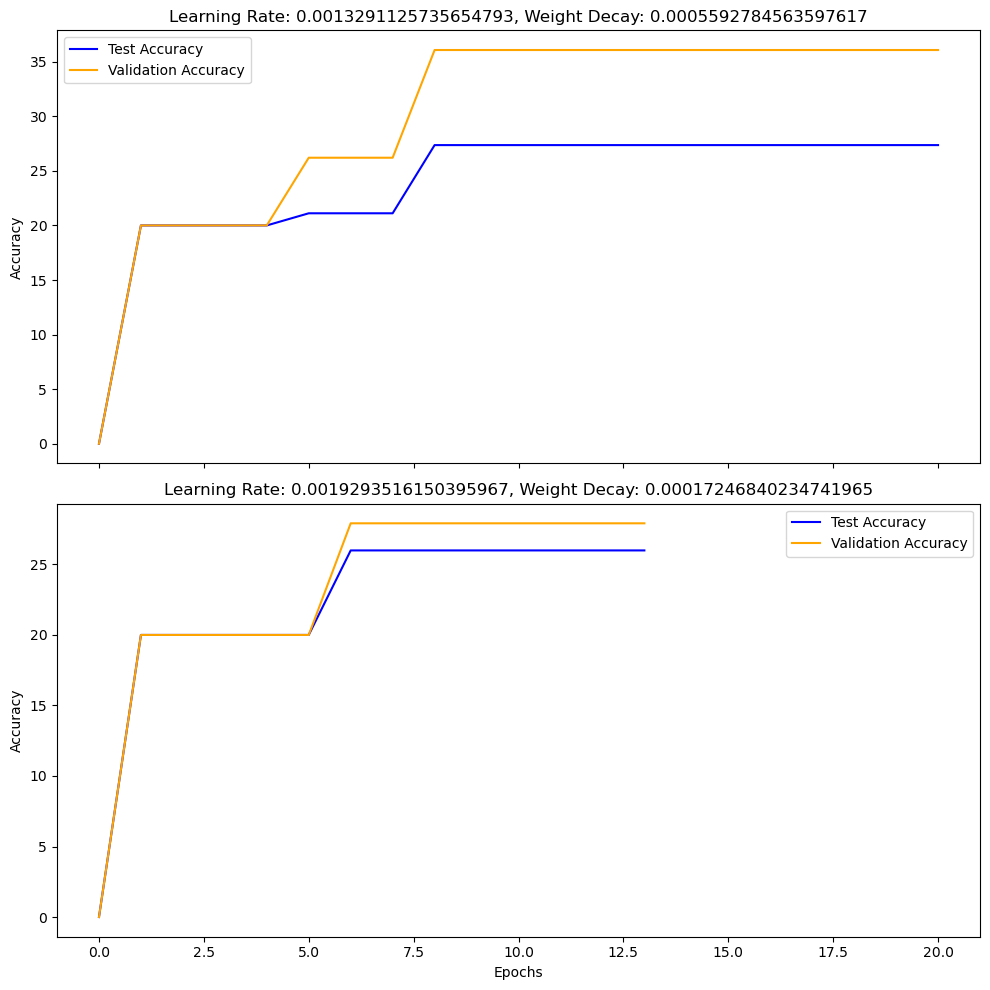

In [34]:
import pickle
import matplotlib.pyplot as plt

# Load the hyperparameter combinations
with open('global_stats/hypercombo_iteratethrough_list.pkl', 'rb') as file:
    hypercombo_list = pickle.load(file)

# Load the accuracy data
with open('global_stats/global_best_test_raw_acc_at_val_list_parallel.pkl', 'rb') as file:
    test_accuracy_data = pickle.load(file)

with open('global_stats/global_best_val_raw_acc_list_parallel.pkl', 'rb') as file:
    val_accuracy_data = pickle.load(file)

# Set up the figure for subplots
num_plots = len(hypercombo_list)
fig, axs = plt.subplots(num_plots, 1, figsize=(10, 5 * num_plots), sharex=True)

# Iterate through each hyperparameter combination
for i, (hypercombo, test_acc, val_acc) in enumerate(zip(hypercombo_list, test_accuracy_data, val_accuracy_data)):
    # Extract learning rate and weight decay from the hypercombo
    lr = hypercombo['lr']
    wd = hypercombo['wd']
    
    # Plot test and validation accuracy
    axs[i].plot(test_acc, label='Test Accuracy', color='blue')
    axs[i].plot(val_acc, label='Validation Accuracy', color='orange')
    
    # Set title and labels
    axs[i].set_title(f'Learning Rate: {lr}, Weight Decay: {wd}')
    axs[i].set_ylabel('Accuracy')
    axs[i].legend()
    
# Set common x-label
axs[-1].set_xlabel('Epochs')

# Show the plot
plt.tight_layout()
plt.show()
